In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings("ignore")

In [2]:
data=pd.read_csv("transactions.csv")

In [3]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,8,CASH_OUT,158007.12,C424875646,0.00,0.00,C1298177219,474016.32,1618631.97,0
1,236,CASH_OUT,457948.30,C1342616552,0.00,0.00,C1323169990,2720411.37,3178359.67,0
2,37,CASH_IN,153602.99,C900876541,11160428.67,11314031.67,C608741097,3274930.56,3121327.56,0
3,331,CASH_OUT,49555.14,C177696810,10865.00,0.00,C462716348,0.00,49555.14,0
4,250,CASH_OUT,29648.02,C788941490,0.00,0.00,C1971700992,56933.09,86581.10,0


In [4]:
print("Total records in data:",data.shape[0])
print("Total features in data:",data.shape[1])

Total records in data: 199999
Total features in data: 10


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199999 entries, 0 to 199998
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            199999 non-null  int64  
 1   type            199999 non-null  object 
 2   amount          199999 non-null  float64
 3   nameOrig        199999 non-null  object 
 4   oldbalanceOrg   199999 non-null  float64
 5   newbalanceOrig  199999 non-null  float64
 6   nameDest        199999 non-null  object 
 7   oldbalanceDest  199999 non-null  float64
 8   newbalanceDest  199999 non-null  float64
 9   isFraud         199999 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 15.3+ MB


In [6]:
data.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
dtype: object

In [7]:
data.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [8]:
unique_values={col:data[col].unique() for col in data.columns}
unique_values

{'step': array([  8, 236,  37, 331, 250, 182, 355, 302,  35, 156, 378, 139, 180,
        184,  48, 403, 254, 279,  16, 644, 141, 179, 154, 258, 155,  43,
        277, 251, 163,  45, 332, 187,  19, 186, 428, 213, 399, 209, 404,
        161, 370, 286, 204, 371, 253, 189, 500,  44, 153, 283, 228, 201,
        207, 273, 347, 235, 322, 178, 160, 256, 230, 202, 354, 132, 162,
         20,  34, 398, 329, 305, 350, 287, 328, 203,  38, 262, 125, 345,
        395, 372, 406, 359, 306, 234, 596, 257, 393, 353, 402, 567, 326,
        131, 369, 226, 276, 681, 120, 307, 714, 401, 544, 133, 280, 407,
        185, 321, 451, 282,  15, 260, 379,  21, 324, 310, 394, 239, 374,
        134, 405, 233, 380,  13,  11, 136, 217, 351, 299, 157, 323, 327,
        285, 278,  18, 119,  41, 346, 263, 514, 142,  17,  42,  10,  22,
        274, 361, 227, 333, 231, 212, 284, 330, 232, 208, 158, 356, 164,
        137, 376, 188,  33, 165, 304, 135, 375, 130, 177, 573,  36, 686,
        670, 373, 144, 381, 325, 249,  14, 

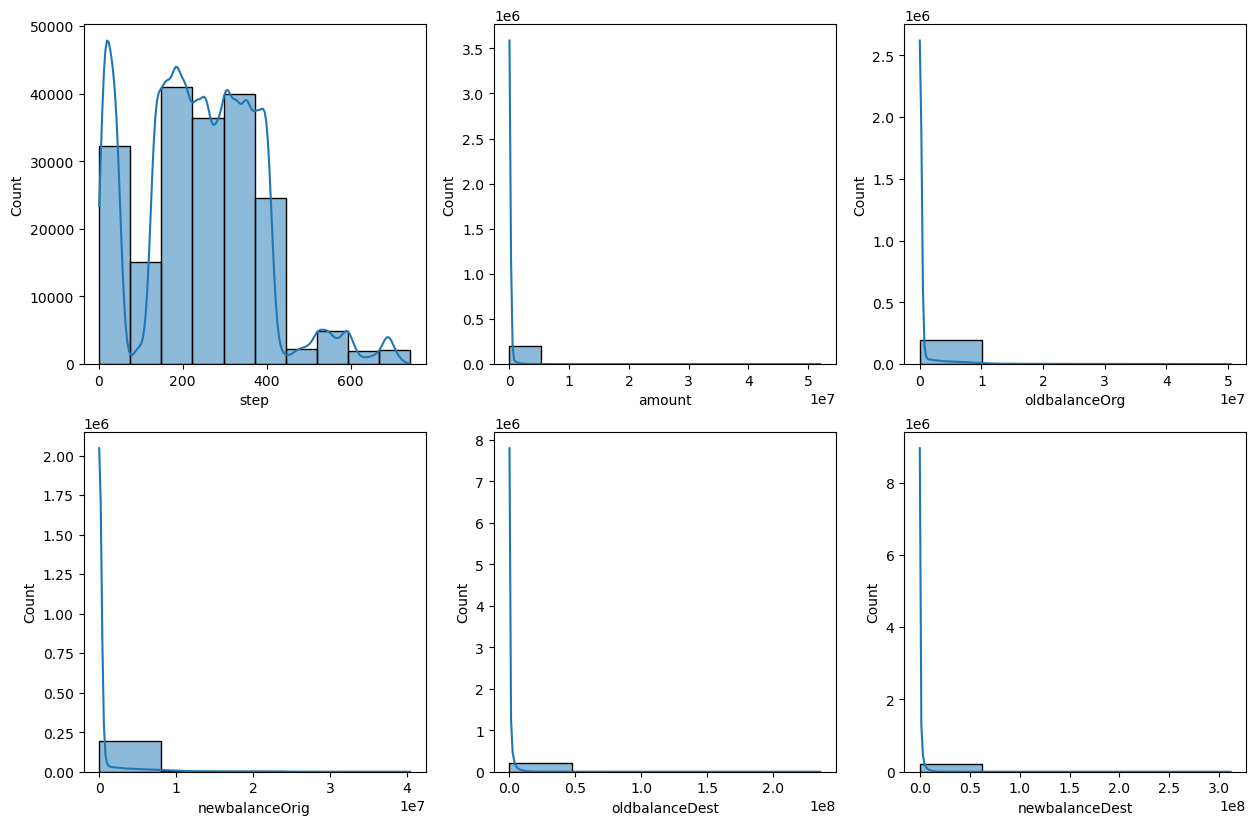

In [9]:
plt.figure(figsize=(15,15))
plt.subplot(3,3,1)
sns.histplot(data["step"],kde=True,bins=10)
plt.subplot(3,3,2)
sns.histplot(data["amount"],kde=True,bins=10)
plt.subplot(3,3,3)
sns.histplot(data["oldbalanceOrg"],kde=True,bins=5)
plt.subplot(3,3,4)
sns.histplot(data["newbalanceOrig"],kde=True,bins=5)
plt.subplot(3,3,5)
sns.histplot(data["oldbalanceDest"],kde=True,bins=5)
plt.subplot(3,3,6)
sns.histplot(data["newbalanceDest"],kde=True,bins=5)
plt.show()

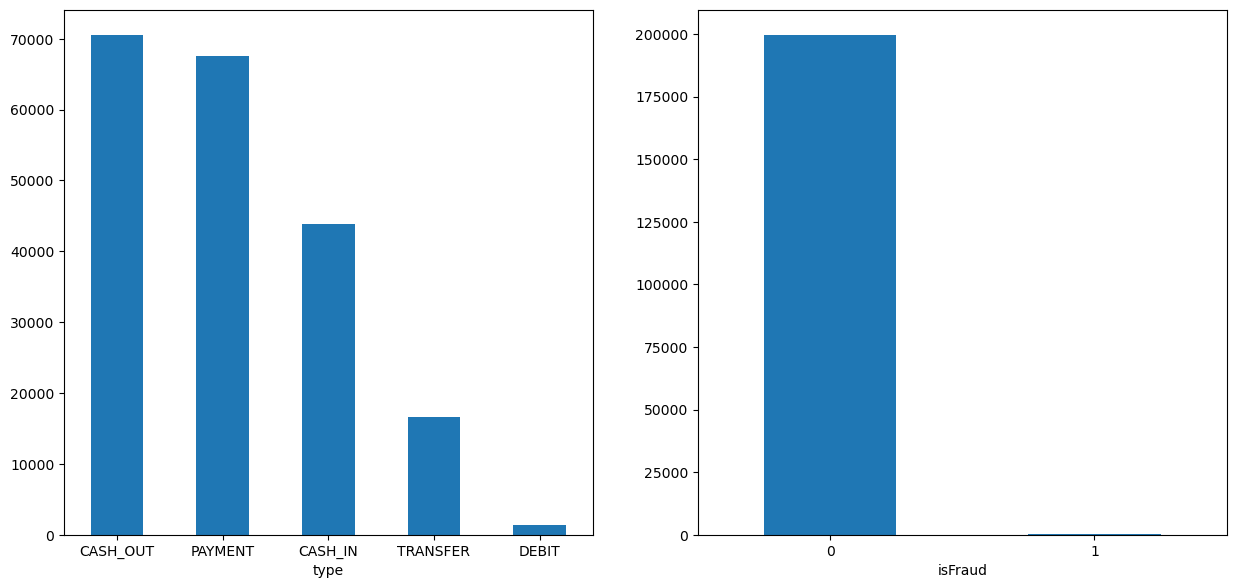

In [10]:
plt.figure(figsize=(15,15))
plt.subplot(2,2,1)
data["type"].value_counts().plot(kind="bar")
plt.xticks(rotation=0)
plt.subplot(2,2,2)
data["isFraud"].value_counts().plot(kind="bar")
plt.xticks(rotation=0)
plt.show()

In [11]:
data["isFraud"].value_counts()

isFraud
0    199717
1       282
Name: count, dtype: int64

In [12]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(sparse_output=False)
encode_data=pd.DataFrame(encoder.fit_transform(data[["type"]]),columns=encoder.get_feature_names_out())
encode_data.head()

,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0


In [13]:
data=pd.concat([data.drop(["type","nameOrig","nameDest"],axis=1),encode_data],axis=1)
data.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,8,158007.12,0.00,0.00,474016.32,1618631.97,0,0.0,1.0,0.0,0.0,0.0
1,236,457948.30,0.00,0.00,2720411.37,3178359.67,0,0.0,1.0,0.0,0.0,0.0
2,37,153602.99,11160428.67,11314031.67,3274930.56,3121327.56,0,1.0,0.0,0.0,0.0,0.0
3,331,49555.14,10865.00,0.00,0.00,49555.14,0,0.0,1.0,0.0,0.0,0.0
4,250,29648.02,0.00,0.00,56933.09,86581.10,0,0.0,1.0,0.0,0.0,0.0


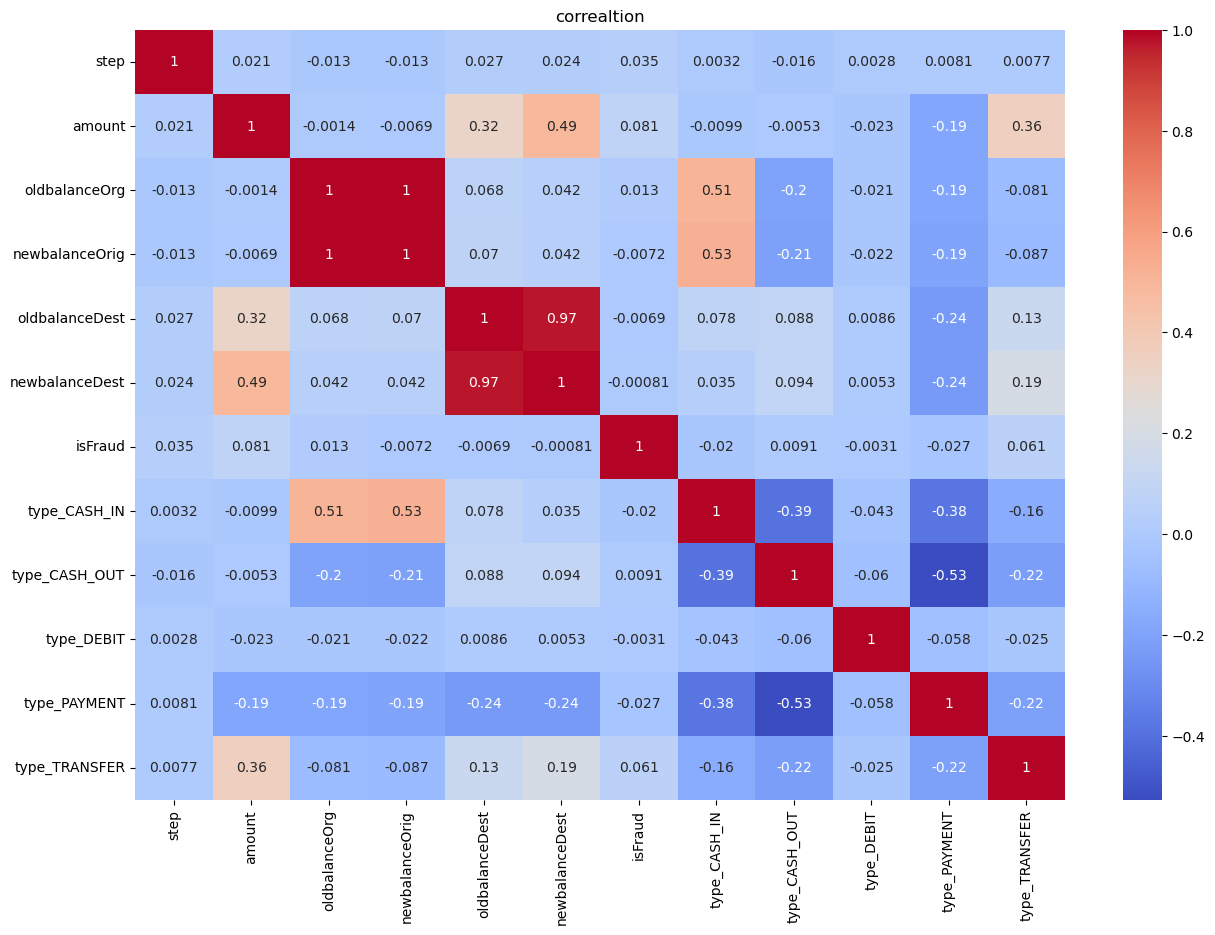

In [14]:
corr=data.corr()
plt.figure(figsize=(15,10))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("correaltion")
plt.show()

In [15]:
x=data.drop(["isFraud"],axis=1)
y=data["isFraud"]

In [16]:
from sklearn.model_selection import train_test_split
train_x,test_x,train_y,test_y=train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
train_y.value_counts()

isFraud
0    159771
1       228
Name: count, dtype: int64

In [18]:
from imblearn.over_sampling import SMOTE
sampling=SMOTE()
train_x,train_y=sampling.fit_resample(train_x,train_y)

In [19]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
scale.fit(train_x)
scale_train_x=scale.transform(train_x)
scale_test_x=scale.transform(test_x)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [21]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score,roc_auc_score

In [22]:
def get_metrics(actual,predicted):
    acc=accuracy_score(actual,predicted)
    cf=confusion_matrix(actual,predicted)
    pr=precision_score(actual,predicted)
    rc=recall_score(actual,predicted)
    f1=f1_score(actual,predicted)
    roc=roc_auc_score(actual,predicted)
    return acc,cf,pr,rc,f1,roc

In [23]:
models={
    "LogisticRegression":LogisticRegression(),
    "DecisionTreeClassifier":DecisionTreeClassifier(),
    "RandomForestClassifier":RandomForestClassifier(),
    "AdaBoostClassifier":AdaBoostClassifier(),
    "XGBClassifier":XGBClassifier(),
    "BernoulliNB":BernoulliNB(),
    "KNeighborsClassifier":KNeighborsClassifier()
}

In [24]:
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(scale_train_x,train_y)

    train_pred=model.predict(scale_train_x)
    test_pred=model.predict(scale_test_x)

    train_acc,train_cf,train_pr,train_rc,train_f1,train_roc=get_metrics(train_y,train_pred)
    test_acc,test_cf,test_pr,test_rc,test_f1,test_roc=get_metrics(test_y,test_pred)

    print(list(models.keys())[i])
    print("-------------------------------------")
    print("training data:")
    print("-------------------------------------")
    print("accuracy score:",train_acc)
    print("confusion matrix:\n",train_cf)
    print("precision score:",train_pr)
    print("recall score:",train_rc)
    print("f1 score:",train_f1)
    print("roc auc score:",train_roc)
    print("-----------------------------------------------------------")
    print("testing data:")
    print("-------------------------------------")
    print("accuracy score:",test_acc)
    print("confusion matrix:\n",test_cf)
    print("precision score:",test_pr)
    print("recall score:",test_rc)
    print("f1 score:",test_f1)
    print("roc auc score:",test_roc)
    print("=============================================================================")
    print("\n")

LogisticRegression
-------------------------------------
training data:
-------------------------------------
accuracy score: 0.9679541343547953
confusion matrix:
 [[154244   5527]
 [  4713 155058]]
precision score: 0.9655820904816764
recall score: 0.9705015303152638
f1 score: 0.9680355604390116
roc auc score: 0.9679541343547953
-----------------------------------------------------------
testing data:
-------------------------------------
accuracy score: 0.968225
confusion matrix:
 [[38681  1265]
 [    6    48]]
precision score: 0.03655750190403656
recall score: 0.8888888888888888
f1 score: 0.07022677395757132
roc auc score: 0.9286105687122059


DecisionTreeClassifier
-------------------------------------
training data:
-------------------------------------
accuracy score: 1.0
confusion matrix:
 [[159771      0]
 [     0 159771]]
precision score: 1.0
recall score: 1.0
f1 score: 1.0
roc auc score: 1.0
-----------------------------------------------------------
testing data:
------------

In [25]:
from sklearn.model_selection import RandomizedSearchCV 
from sklearn.model_selection import StratifiedKFold

In [26]:
cv=StratifiedKFold()

In [30]:
xgb=XGBClassifier()


n_estimators_xgb=[int(x) for x in np.linspace(start=100,stop=200,num=5)]
max_depth_xgb=[int(x) for x in np.linspace(start=3,stop=30,num=3)]
learning_rate_xgb=[0.1,0.2,0.01,0.02]
min_child_weight_xgb=[1,3,5,7]
subsample_xgb=[0.6,0.8,1.0]
colsample_bytree_xgb=[0.6,0.8,1.0]
reg_lambda_xgb=[1,5,10]
reg_alpha_xgb=[0,0.1,1]


params_xgb=dict(n_estimators=n_estimators_xgb,max_depth=max_depth_xgb,learning_rate=learning_rate_xgb,min_child_weight=min_child_weight_xgb,subsample=subsample_xgb,colsample_bytree=colsample_bytree_xgb,reg_lambda=reg_lambda_xgb,reg_alpha=reg_alpha_xgb)

xgb_tun=RandomizedSearchCV(estimator=xgb,param_distributions=params_xgb,n_iter=10,scoring="accuracy",n_jobs=-1,cv=cv,verbose=3)

xgb_tun.fit(scale_train_x,train_y)

xgb_train_pred=xgb_tun.predict(scale_train_x)
xgb_test_pred=xgb_tun.predict(scale_test_x)


train_acc,train_cf,train_pr,train_rc,train_f1,train_roc=get_metrics(train_y,xgb_train_pred)
test_acc,test_cf,test_pr,test_rc,test_f1,test_roc=get_metrics(test_y,xgb_test_pred)

print("Hyperparameter tuning XGBClassifier")
print("-------------------------------------")
print("training data:")
print("-------------------------------------")
print("accuracy score:",train_acc)
print("confusion matrix:\n",train_cf)
print("precision score:",train_pr)
print("recall score:",train_rc)
print("f1 score:",train_f1)
print("roc auc score:",train_roc)
print("-----------------------------------------------------------")
print("testing data:")
print("-------------------------------------")
print("accuracy score:",test_acc)
print("confusion matrix:\n",test_cf)
print("precision score:",test_pr)
print("recall score:",test_rc)
print("f1 score:",test_f1)
print("roc auc score:",test_roc)
print("=============================================================================")
print("\n")

xgb_tun.best_params_



Fitting 5 folds for each of 10 candidates, totalling 50 fits
Hyperparameter tuning XGBClassifier
-------------------------------------
training data:
-------------------------------------
accuracy score: 0.9996244625119702
confusion matrix:
 [[159651    120]
 [     0 159771]]
precision score: 0.9992494887141865
recall score: 1.0
f1 score: 0.9996246034874336
roc auc score: 0.9996244625119702
-----------------------------------------------------------
testing data:
-------------------------------------
accuracy score: 0.998525
confusion matrix:
 [[39899    47]
 [   12    42]]
precision score: 0.47191011235955055
recall score: 0.7777777777777778
f1 score: 0.5874125874125874
roc auc score: 0.8883005946917227




{'subsample': 0.8,
 'reg_lambda': 1,
 'reg_alpha': 0.1,
 'n_estimators': 150,
 'min_child_weight': 1,
 'max_depth': 30,
 'learning_rate': 0.02,
 'colsample_bytree': 0.6}